In [25]:
from pathlib import Path
import re
import csv
import torch
from torch.utils.data import Dataset
from PIL import Image
import math

import matplotlib.pyplot as plt
%matplotlib inline

In [136]:
def relative_angle_to(target_x, target_y, self_x, self_y, self_heading_deg):
    dx = target_x - self_x
    dy = target_y - self_y
    world_bearing = math.degrees(math.atan2(dy, dx))       # [-180,180)
    rel = world_bearing - self_heading_deg
    rel = (rel + 180) % 360 - 180                           # wrap to [-180,180)
    return rel

def relative_distance_to(target_x, target_y, self_x, self_y):
    return math.hypot(target_x - self_x, target_y - self_y)

def calculate_dist_angles(pos_dict):
    sx, sy, sh = pos_dict['self_pose_x'], pos_dict['self_pose_y'], pos_dict['self_pose_angle']
    agents = sorted({key.split('_pose')[0] for key in pos_dict if '_pose' in key and not key.startswith('self')})

    angles = []
    dists = []
    for agent in agents:
        angles.append(relative_angle_to(pos_dict[f'{agent}_pose_x'], pos_dict[f'{agent}_pose_y'], sx, sy, sh))
        dists.append(relative_distance_to(pos_dict[f'{agent}_pose_x'], pos_dict[f'{agent}_pose_y'], sx, sy))

    return dists, angles

def confidence_from_angle(angle_deg):
    a = abs(angle_deg)  # use absolute angle
    midpoint = 30
    k = 1.0  # steepness — higher = sharper transition
    return 1 / (1 + math.exp(k * (a - midpoint)))

class ImageCSVDataset(Dataset):
    def __init__(self, roots, csv_glob="*.csv", img_col=0, label_cols=None,
                 keep_last_n_levels=None, transform=None, target_transform=None, strict=False, ts_shift=None, oob_threshold=30):
        self.roots = [Path(r) for r in roots]
        self.csv_glob = csv_glob
        self.img_col = img_col
        self.label_cols = label_cols
        self.keep_last_n_levels = keep_last_n_levels  # <<< e.g. 2
        self.transform = transform
        self.target_transform = target_transform
        self.strict = strict
        self.ts_shift = ts_shift
        self.oob_threshold = oob_threshold
        self.samples = []
        self._build_index()

    def _split_anysep(self, s: str):
        # split on / or \ (handles Windows paths stored in CSV)
        return [p for p in re.split(r"[\\/]+", s) if p]

    def _rebase_to_csv_dir(self, csv_dir: Path, orig: str) -> Path:
        parts = self._split_anysep(orig)
        if self.keep_last_n_levels is not None and len(parts) >= self.keep_last_n_levels:
            parts = parts[-self.keep_last_n_levels:]
        # Build a path under the CSV directory with those last N components
        return csv_dir.joinpath(*parts)

    def _build_index(self):
        for root in self.roots:
            for csv_path in root.rglob(self.csv_glob):
                rows = list(csv.reader(open(csv_path, "r", newline="")))
                if not rows:
                    continue
                # NEW: store header row (first row in CSV)
                header = rows[0]  # first row is header
                # NEW: resolve label indices from user selection
                def to_idx(x):
                    return x if isinstance(x, int) else header.index(x)  # name -> index

                all_label_idxs = [i for i in range(len(header)) if i != self.img_col]

                if self.label_cols is not None:
                    keep = [to_idx(x) for x in self.label_cols if to_idx(x) != self.img_col]
                else:
                    keep = all_label_idxs

                label_names = [header[i] for i in keep]

                # start from row 1 (skip header)
                for i, row in enumerate(rows[1:], start=1):
                    if len(row) <= self.img_col:
                        if self.strict: raise ValueError(f"Bad row {i} in {csv_path}")
                        continue

                    if row[self.img_col] == 'none':
                        # raise ValueError(f"Bad row {i} in {csv_path}")
                        continue

                    orig_path_str = row[self.img_col].strip()

                    # >>> Rebase: keep last 2 levels relative to the CSV folder
                    img_path = self._rebase_to_csv_dir(csv_path.parent, orig_path_str)
                    # <<<

                    if not img_path.exists():
                        if self.strict:
                            raise FileNotFoundError(f"Image not found after rebasing: {img_path} (from {csv_path}:{i})")
                        else:
                            continue

                    try:
                        if self.ts_shift is None:
                            # NEW: create label dict keyed by header names
                            label_dict = {header[idx]: float(row[idx]) for idx in keep}
                        else:
                            label_dict = {header[idx]: float(rows[i-self.ts_shift][idx]) for idx in keep}

                        has_nan = any(math.isnan(v) for v in label_dict.values() if isinstance(v, (float, int)))
                        if has_nan:
                            if self.strict:
                                raise ValueError(f"Label parse error at {csv_path}:{i}: {e}")
                            else:
                                continue
                    except Exception as e:
                        if self.strict:
                            raise ValueError(f"Label parse error at {csv_path}:{i}: {e}")
                        else:
                            continue

                    rel_dists, rel_angles = calculate_dist_angles(label_dict)
                    
                    label_tensor = torch.tensor([rel_dists, rel_angles, [confidence_from_angle(ang) for ang in rel_angles]]).T

                    # blank_image = True
                    # for car_id, angle in enumerate(rel_angles):
                    #     if abs(angle) < self.oob_threshold:
                    #         blank_image = False


                    label_dict['label_tensor'] = label_tensor
                    self.samples.append((img_path, label_dict))

        if not self.samples and self.strict:
            raise RuntimeError("No samples indexed.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        p, label_dict = self.samples[idx]
        with Image.open(p) as im:
            im = im.convert("RGB")
        x = self.transform(im) if self.transform else torch.from_numpy(
            (torch.ByteTensor(torch.ByteStorage.from_buffer(im.tobytes()))
             .view(im.size[1], im.size[0], 3)
             .permute(2, 0, 1).float() / 255.0).numpy()
        )
        y = self.target_transform(label_dict) if self.target_transform else label_dict
        return x, y

In [301]:
import csv, math, re, bisect
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset

# --- your helpers unchanged ---
def relative_angle_to(target_x, target_y, self_x, self_y, self_heading_deg):
    dx = target_x - self_x
    dy = target_y - self_y
    world_bearing = math.degrees(math.atan2(dy, dx))       # [-180,180)
    rel = world_bearing - self_heading_deg
    rel = (rel + 180) % 360 - 180                           # wrap to [-180,180)
    return rel

def relative_distance_to(target_x, target_y, self_x, self_y):
    return math.hypot(target_x - self_x, target_y - self_y)

def calculate_dist_angles(pos_dict):
    sx, sy, sh = pos_dict['self_pose_x'], pos_dict['self_pose_y'], pos_dict['self_pose_angle']
    agents = sorted({key.split('_pose')[0] for key in pos_dict if '_pose' in key and not key.startswith('self')})

    angles = []
    dists = []
    for agent in agents:
        angles.append(relative_angle_to(pos_dict[f'{agent}_pose_x'], pos_dict[f'{agent}_pose_y'], sx, sy, sh))
        dists.append(relative_distance_to(pos_dict[f'{agent}_pose_x'], pos_dict[f'{agent}_pose_y'], sx, sy))

    return dists, angles

def confidence_from_angle(angle_deg):
    a = abs(angle_deg)
    midpoint = 30
    k = 1.0
    return 1 / (1 + math.exp(k * (a - midpoint)))

# --- updated dataset ---
class ImageCSVDataset(Dataset):
    def __init__(
        self,
        roots,
        csv_glob="*.csv",
        img_col=0,                         # still supported (index or name)
        label_cols=None,                   # optional: restrict which pose columns to keep
        keep_last_n_levels=None,
        transform=None,
        target_transform=None,
        strict=False,
        ts_shift=None,                     
        oob_threshold=30,
        img_col_name='image',              # NEW
        img_ts_col='image_timestamp',      # NEW
        pose_ts_col='pose_stamp',          # NEW
        max_time_diff=None                 # NEW: seconds; if set, drop pairs farther than this
    ):
        self.roots = [Path(r) for r in roots]
        self.csv_glob = csv_glob
        self.img_col = img_col
        self.label_cols = label_cols
        self.keep_last_n_levels = keep_last_n_levels
        self.transform = transform
        self.target_transform = target_transform
        self.strict = strict
        self.ts_shift = 0 if ts_shift is None else ts_shift
        self.oob_threshold = oob_threshold

        self.img_col_name = img_col_name
        self.img_ts_col = img_ts_col
        self.pose_ts_col = pose_ts_col
        self.max_time_diff = max_time_diff

        self.samples = []
        self._build_index()

    def _split_anysep(self, s: str):
        return [p for p in re.split(r"[\\/]+", s) if p]

    def _rebase_to_csv_dir(self, csv_dir: Path, orig: str) -> Path:
        parts = self._split_anysep(orig)
        if self.keep_last_n_levels is not None and len(parts) >= self.keep_last_n_levels:
            parts = parts[-self.keep_last_n_levels:]
        return csv_dir.joinpath(*parts)

    @staticmethod
    def _to_float_safe(x):
        try:
            return float(x)
        except Exception:
            return None

    @staticmethod
    def _closest_index(sorted_vals, val):
        """Return index of closest value to 'val' in a sorted list 'sorted_vals'."""
        if not sorted_vals:
            return None
        i = bisect.bisect_left(sorted_vals, val)
        if i == 0:
            return 0
        if i == len(sorted_vals):
            return len(sorted_vals) - 1
        # choose closer of neighbors
        before = sorted_vals[i - 1]
        after = sorted_vals[i]
        return i - 1 if (val - before) <= (after - val) else i

    def _build_index(self):
        for root in self.roots:
            for csv_path in root.rglob(self.csv_glob):
                with open(csv_path, "r", newline="") as f:
                    rows = list(csv.reader(f))
                if not rows:
                    continue

                header = rows[0]

                # map helper: accept int index or column name
                def col_idx(val_or_idx, default_name=None):
                    if isinstance(val_or_idx, int):
                        return val_or_idx
                    name = val_or_idx if val_or_idx is not None else default_name
                    try:
                        return header.index(name)
                    except ValueError:
                        if self.strict:
                            raise ValueError(f"Column '{name}' not found in {csv_path}")
                        return None

                img_idx = col_idx(self.img_col, self.img_col_name)
                img_ts_idx = col_idx(None, self.img_ts_col)
                pose_ts_idx = col_idx(None, self.pose_ts_col)
                if img_idx is None or img_ts_idx is None or pose_ts_idx is None:
                    if self.strict:
                        raise ValueError(f"Missing required columns in {csv_path}")
                    continue

                # Decide which pose columns to keep: everything except image + image_timestamp + pose_stamp
                excluded = {img_idx, img_ts_idx, pose_ts_idx}
                if self.label_cols is not None:
                    keep_pose_idxs = [c if isinstance(c, int) else header.index(c)
                                      for c in self.label_cols
                                      if (c if isinstance(c, int) else header.index(c)) not in excluded]
                else:
                    keep_pose_idxs = [i for i in range(len(header)) if i not in excluded]

                pose_names = [header[i] for i in keep_pose_idxs]

                # Pass 1: collect pose rows (timestamp -> dict of pose fields)
                pose_list = []   # list of (pose_ts, pose_dict)
                for i, row in enumerate(rows[1:], start=1):
                    if len(row) <= pose_ts_idx:
                        continue
                    ts = self._to_float_safe(row[pose_ts_idx])
                    if ts is None:
                        continue
                    # parse pose values
                    pose_dict = {}
                    bad = False
                    for idx, name in zip(keep_pose_idxs, pose_names):
                        if idx >= len(row):
                            bad = True; break
                        v = self._to_float_safe(row[idx])
                        if v is None or (isinstance(v, float) and math.isnan(v)):
                            bad = True; break
                        pose_dict[name] = v
                    if bad:
                        continue
                    pose_list.append((ts, pose_dict))

                # sort by pose timestamp for binary search
                pose_list.sort(key=lambda x: x[0])
                pose_ts_sorted = [t for t, _ in pose_list]

                # Pass 2: iterate image rows, match nearest pose by timestamp
                for i, row in enumerate(rows[1:], start=1):
                    if len(row) <= max(img_idx, img_ts_idx):
                        if self.strict:
                            raise ValueError(f"Bad row {i} in {csv_path}")
                        continue

                    img_path_str = row[img_idx].strip()
                    if img_path_str.lower() == 'none' or img_path_str == '':
                        continue

                    img_path = self._rebase_to_csv_dir(csv_path.parent, img_path_str)

                    if not img_path.exists():
                        if self.strict:
                            raise FileNotFoundError(f"Image not found after rebasing: {img_path} (from {csv_path}:{i})")
                        continue

                    img_ts = self._to_float_safe(row[img_ts_idx])
                    if img_ts is None:
                        if self.strict:
                            raise ValueError(f"Bad image timestamp at {csv_path}:{i}")
                        continue

                    # find closest pose row
                    ci = self._closest_index(pose_ts_sorted, img_ts + self.ts_shift)

                    if ci is None:
                        continue
                    pose_ts, pose_dict = pose_list[ci]

                    # optionally enforce max_time_diff
                    if self.max_time_diff is not None and abs(pose_ts - img_ts) > self.max_time_diff:
                        # too far apart; skip
                        continue

                    # build label_dict (pose fields + stamps for reference)
                    label_dict = dict(pose_dict)  # copy
                    label_dict[self.pose_ts_col] = pose_ts
                    label_dict[self.img_ts_col] = img_ts

                    try:
                        rel_dists, rel_angles = calculate_dist_angles(label_dict)
                        label_tensor = torch.tensor([
                            rel_dists,
                            rel_angles,
                            [confidence_from_angle(ang) for ang in rel_angles]
                        ]).T
                        label_dict['label_tensor'] = label_tensor
                    except Exception as e:
                        if self.strict:
                            raise
                        else:
                            # if pose fields incomplete for dist/angle calc, still keep raw dict
                            pass

                    self.samples.append((img_path, label_dict))

        if not self.samples and self.strict:
            raise RuntimeError("No samples indexed.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        p, label_dict = self.samples[idx]
        with Image.open(p) as im:
            im = im.convert("RGB")
        x = self.transform(im) if self.transform else torch.from_numpy(
            (torch.ByteTensor(torch.ByteStorage.from_buffer(im.tobytes()))
             .view(im.size[1], im.size[0], 3)
             .permute(2, 0, 1).float() / 255.0).numpy()
        )
        y = self.target_transform(label_dict) if self.target_transform else label_dict
        return x, y

In [316]:
from torchvision import transforms

img_trans = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

ds = ImageCSVDataset(
    roots=["/Users/ruiheng/Documents/Study/picar/2025_training/2025_0813_1543-S1"],
    img_col_name='image',
    img_ts_col='image_timestamp',
    pose_ts_col='pose_timestamp',
    # label_cols=list(range(2,3+9)),
    keep_last_n_levels=2,     # <<< only keep last two components
    transform=img_trans,
    # strict=False,
    ts_shift=0 #6e5 #15
)

ds = ImageCSVDataset(
    roots=["/Users/ruiheng/Documents/Study/picar/2025_training/2025_0813_1543-S2"],
    img_col_name='image',
    img_ts_col='image_timestamp',
    pose_ts_col='pose_timestamp',
    # label_cols=list(range(2,3+9)),
    keep_last_n_levels=2,     # <<< only keep last two components
    transform=img_trans,
    # strict=False,
    # ts_shift=18 #15
)

print(len(ds))

3693


In [271]:
print(6e5)

600000.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


{'car_S1_pose_x': -686.1932373046875, 'car_S1_pose_y': 189.93417358398438, 'car_S1_pose_angle': -8.568641662597656, 'self_pose_x': -626.7574462890625, 'self_pose_y': 540.5950927734375, 'self_pose_angle': 24.26417350769043, 'car_S3_pose_x': 454.67767333984375, 'car_S3_pose_y': 261.5767517089844, 'car_S3_pose_angle': 55.99437713623047, 'pose_timestamp': 1.7550921373254758e+18, 'image_timestamp': 1.755092137326666e+18, 'label_tensor': tensor([[ 3.5566e+02, -1.2388e+02,  1.6851e-41],
        [ 1.1168e+03, -3.8731e+01,  1.6141e-04]])}
tensor([[ 3.5566e+02, -1.2388e+02,  1.6851e-41],
        [ 1.1168e+03, -3.8731e+01,  1.6141e-04]])


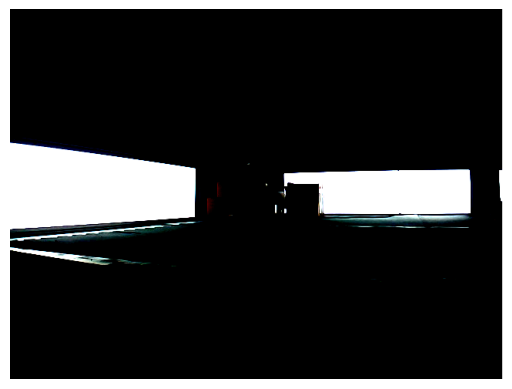

In [318]:
img, labels = ds[25]   # index into dataset
print(labels)         # see the label dict
print(labels['label_tensor'])

plt.imshow(img.permute(1, 2, 0).numpy())
plt.axis('off')
plt.show()

In [11]:
import re
import numpy as np
import matplotlib.pyplot as plt

def plot_poses(pose_dict, arrow_len=220):
    """
    pose_dict: flat dict with keys like '<name>_pose_x', '<name>_pose_y', '<name>_pose_angle' (degrees)
               e.g., 'car_S1_pose_x', 'self_pose_angle', etc.
    arrow_len: length of the heading arrow in plotting units
    """
    # 1) Group fields by agent name
    agents = {}
    pat = re.compile(r'^(?P<name>.+)_pose_(?P<field>x|y|angle)$')
    for k, v in pose_dict.items():
        m = pat.match(k)
        if not m:
            continue
        d = agents.setdefault(m.group('name'), {})
        d[m.group('field')] = float(v)

    # 2) Prepare plot
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_xlim(-1200, 1200)
    ax.set_ylim(-1200, 1200)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    # boundary box
    ax.add_patch(plt.Rectangle((-1200, -1200), 2400, 2400, fill=False, lw=2, ls='--'))

    # 3) Plot each agent
    for name, d in agents.items():
        if not all(k in d for k in ('x','y','angle')):
            continue
        x, y = d['x'], d['y']
        theta = np.deg2rad(d['angle'])  # 0°=+x, CCW in math coords
        u, v = np.cos(theta)*arrow_len, np.sin(theta)*arrow_len

        # point + heading arrow
        ax.plot(x, y, 'o', ms=8, label=name)
        ax.quiver(x, y, u, v, angles='xy', scale_units='xy', scale=1, width=0.008)

        # label near the point
        ax.text(x+10, y+10, name, fontsize=9)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Agent positions and headings')
    # ax.legend(loc='upper right', fontsize=8)
    plt.show()

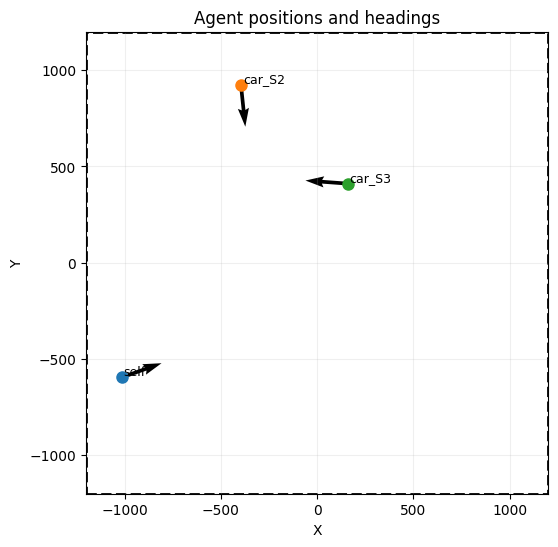

In [299]:
plot_poses(labels)

In [ ]:
import re
import numpy as np
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- utils ---
def to_numpy_img(img, mean=None, std=None):
    """path/PIL/tensor/ndarray -> float32 HWC in [0,1], optional unnormalize."""
    if isinstance(img, (str, Path)):
        img = Image.open(img).convert("RGB")
    if isinstance(img, Image.Image):
        arr = np.array(img).astype(np.float32) / 255.0
    elif isinstance(img, torch.Tensor):
        x = img.detach().cpu()
        if x.dtype == torch.uint8: x = x.float() / 255.0
        if x.ndim == 3 and x.shape[0] in (1,3,4):  # CHW -> HWC
            x = x.permute(1, 2, 0)
        if x.ndim == 2: x = x.unsqueeze(-1)
        arr = x.numpy()
    elif isinstance(img, np.ndarray):
        arr = img.astype(np.float32)
        if arr.max() > 1.0: arr = arr / 255.0
        if arr.ndim == 2: arr = arr[..., None]
    else:
        raise TypeError(f"Unsupported image type: {type(img)}")

    if mean is not None and std is not None:
        mean = np.array(mean, dtype=np.float32).reshape(1,1,-1)
        std  = np.array(std,  dtype=np.float32).reshape(1,1,-1)
        arr = arr * std + mean

    if arr.shape[-1] == 1:
        arr = np.repeat(arr, 3, axis=-1)
    return np.clip(arr, 0.0, 1.0)

def draw_pose_subplot(ax, pose_dict, arrow_len=220):
    ax.clear()
    ax.set_xlim(-1200, 1200); ax.set_ylim(-1200, 1200)
    ax.set_aspect('equal', adjustable='box'); ax.grid(True, alpha=0.2)
    ax.add_patch(plt.Rectangle((-1200,-1200), 2400, 2400, fill=False, lw=2, ls='--'))

    # group fields by agent name: "<name>_pose_{x|y|angle}"
    agents, pat = {}, re.compile(r'^(?P<name>.+)_pose_(?P<field>x|y|angle)$')
    for k, v in pose_dict.items():
        m = pat.match(k); 
        if not m: continue
        d = agents.setdefault(m.group('name'), {})
        d[m.group('field')] = float(v)

    for name, d in agents.items():
        if not all(k in d for k in ('x','y','angle')): continue
        x, y = d['x'], d['y']
        th = np.deg2rad(d['angle'])
        u, v = np.cos(th)*arrow_len, np.sin(th)*arrow_len
        ax.plot(x, y, 'o', ms=8)
        ax.quiver(x, y, u, v, angles='xy', scale_units='xy', scale=1, width=0.008)
        ax.text(x+10, y+10, name, fontsize=9)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_title('Agent positions & headings')

# --- animate directly from a Dataset ---
def animate_dataset(ds, indices=None, fps=2, save_path=None, title_key=None,
                    unnormalize_mean=None, unnormalize_std=None):
    """
    ds: PyTorch Dataset where ds[i] -> (image, pose_dict)  OR {'image': ..., 'pose': ...}
    indices: list of indices to animate (default: range(len(ds)))
    title_key: optional key inside pose_dict to show as title (e.g., 'label' or 'timestamp')
    """
    if indices is None:
        indices = range(len(ds))

    fig, (ax_img, ax_pose) = plt.subplots(1, 2, figsize=(10,5))

    def update(k):
        i = indices[k]
        sample = ds[i]
        # support tuple or dict
        if isinstance(sample, dict):
            img, pose = sample.get('image'), sample.get('pose') or sample.get('poses')
        else:
            img, pose = sample

        ax_img.clear()
        arr = to_numpy_img(img, mean=unnormalize_mean, std=unnormalize_std)
        ax_img.imshow(arr); ax_img.axis('off')
        title = f"idx={i}"
        if isinstance(pose, dict) and title_key in pose if title_key else False:
            title = str(pose[title_key])
        ax_img.set_title(title)

        draw_pose_subplot(ax_pose, pose)

    anim = FuncAnimation(fig, update, frames=len(indices), interval=1000/fps, repeat=False)
    if save_path:
        anim.save(save_path, fps=fps, dpi=150)
    else:
        plt.show()

# --- optional: animate from a DataLoader (any batch size) ---
def animate_dataloader(loader, max_frames=None, fps=2, save_path=None,
                       title_key=None, unnormalize_mean=None, unnormalize_std=None):
    frames = []
    for batch in loader:
        # support dict or tuple batches
        if isinstance(batch, dict):
            imgs = batch['image']; poses = batch.get('pose') or batch.get('poses')
        else:
            imgs, poses = batch
        # unbatch
        for img, pose in zip(imgs, poses):
            # pose can be dict-of-lists; convert each element to python scalar
            if isinstance(pose, dict):
                pose = {k: (v.item() if isinstance(v, torch.Tensor) and v.numel()==1 else
                            (v.tolist() if isinstance(v, torch.Tensor) else v))
                        for k, v in pose.items()}
            frames.append((img, pose))
            if max_frames and len(frames) >= max_frames:
                break
        if max_frames and len(frames) >= max_frames:
            break

    fig, (ax_img, ax_pose) = plt.subplots(1, 2, figsize=(10,5))

    def update(k):
        img, pose = frames[k]
        ax_img.clear()
        arr = to_numpy_img(img, mean=unnormalize_mean, std=unnormalize_std)
        ax_img.imshow(arr); ax_img.axis('off')
        ax_img.set_title(f"frame {k}")
        draw_pose_subplot(ax_pose, pose)

    anim = FuncAnimation(fig, update, frames=len(frames), interval=1000/fps, repeat=False)
    if save_path:
        anim.save(save_path, fps=fps, dpi=150)
    else:
        plt.show()

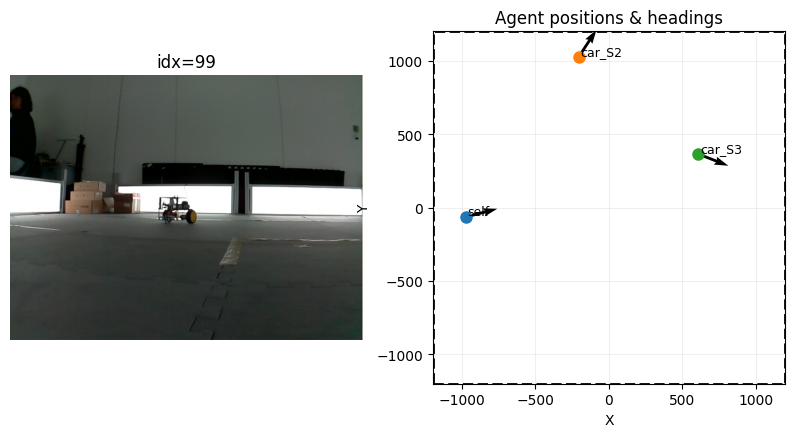

In [290]:
animate_dataset(
    ds, 
    indices=range(0, 100),     # or leave None to use all
    fps=2,
    save_path="./poses.mp4",     # or None to just display
    title_key=None,            # or e.g. 'timestamp' if present in the pose dict
)

In [54]:
img, labels = ds[30]

print(calculate_angles(labels))

[19.72143382380517, -28.751704872697616]
